In [1]:
from typing import Callable, Optional, Sequence, Tuple, Union

import equinox as eqx
import jax
import jax.numpy as jnp
import jax.random as jr
import lrux
import matplotlib.pyplot as plt
import optimistix as optx
import quantax as qtx
from IPython.display import clear_output
from jaxtyping import Key

### Exact Diagonalization


In [2]:
# Model parameters
L = 3
n = 4
diff = 0
t = 1.0
U = 2.0

# diff = n_spin_up - n_spin_down
# diff and n should have the same parity
n_spin_up = (n + diff) // 2
n_spin_down = (n - diff) // 2

lattice.shape=(1, 3, 3)


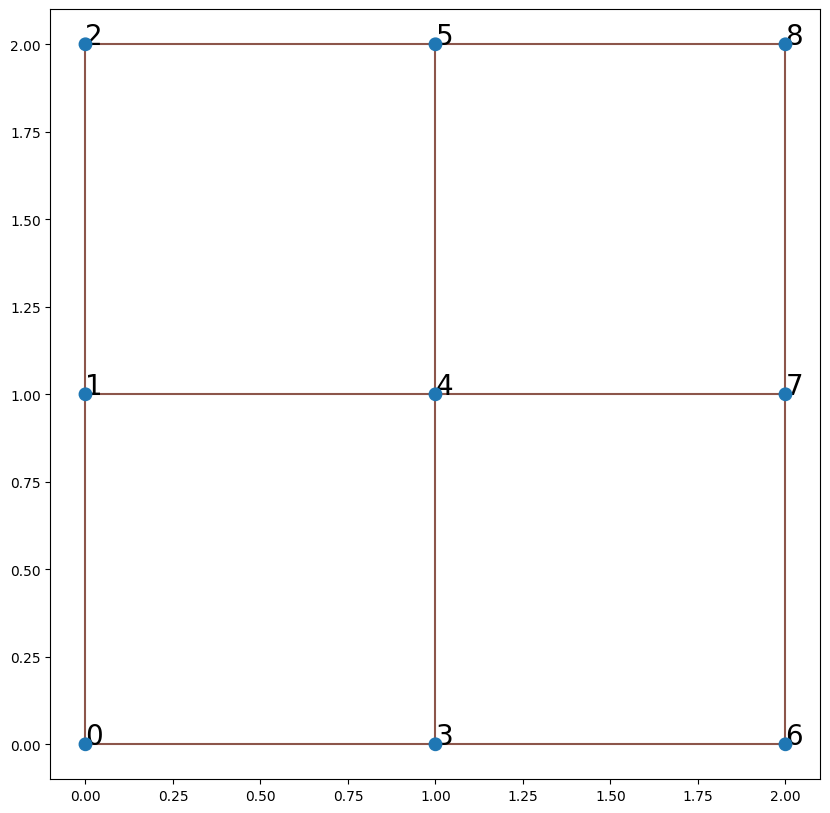

In [3]:
lattice = qtx.sites.Square(
    L,
    particle_type=qtx.PARTICLE_TYPE.spinful_fermion,
    Nparticles=(n_spin_up, n_spin_down),
)
print(f"{lattice.shape=}")
lattice.plot()
plt.show()

In [4]:
# define the Hamiltonian
H = qtx.operator.Hubbard(U, t)

In [ ]:
E, wf = H.diagonalize(k=1)
print(f"GS energy = {E.item()}")

GS = qtx.state.DenseState(wf[:, 0])  # Ground state

In [ ]:
# 1 and -1 denote occupied and unoccupied orbitals, respectively
s = qtx.utils.rand_states()
print("s =", s)  # +1/-1 represents spin-up/down
print("<s|psi0> =", GS(s))

s = [-1 -1 -1  1 -1  1 -1 -1 -1 -1 -1  1 -1 -1 -1 -1 -1  1]
<s|psi0> = [2.27075303e-14]


### Hidden Fermion Pfaffian State (HFPS)


In [ ]:
class CNN_Block(eqx.Module):
    """Residual convolution block"""

    conv1: eqx.nn.Conv
    conv2: eqx.nn.Conv
    # static because we use it for an if-else condition
    block_idx: int = eqx.field(static=True)

    def __init__(
        self,
        channels: int,
        kernel_size: int,
        block_idx: int,
        total_blocks: int,
        dtype=jnp.float32,
    ):
        lattice = qtx.get_lattice()  # should be of shape (1, L, L)
        # periodic boundary conditions
        padding_mode = "CIRCULAR"

        def new_layer(is_first_layer: bool, is_last_layer: bool) -> eqx.nn.Conv:
            if is_first_layer:
                in_channels = lattice.shape[0]  # should be 1
                if lattice.particle_type == qtx.PARTICLE_TYPE.spinful_fermion:
                    in_channels *= 2  # so first layer has in_channels = 2*1 = 2
            else:
                in_channels = channels
            # should generate a new key each time
            key = qtx.get_subkeys()
            conv = eqx.nn.Conv(
                num_spatial_dims=lattice.ndim,  # should be 2
                in_channels=in_channels,
                out_channels=channels,  # out_channels is always the same
                kernel_size=kernel_size,
                padding="SAME",
                use_bias=not is_last_layer,  # i.e. bias for every layer except the last one
                padding_mode=padding_mode,
                dtype=dtype,
                key=key,
            )
            # Notes: stride = dilation = groups = 1 by default
            conv = qtx.nn.apply_he_normal(key, conv)
            return conv

        self.conv1 = new_layer(block_idx == 0, False)
        self.conv2 = new_layer(False, block_idx == (total_blocks - 1))
        self.block_idx = block_idx

    def __call__(self, x: jax.Array) -> jax.Array:
        residual = x.copy()
        x /= jnp.sqrt(self.block_idx + 1)

        if self.block_idx == 0:
            x /= jnp.sqrt(2)
        else:
            x = jax.nn.gelu(x)
        x = self.conv1(x)
        x = jax.nn.gelu(x)
        x = self.conv2(x)

        if x.shape[0] > residual.shape[0]:
            residual = jnp.repeat(residual, x.shape[0] // residual.shape[0], axis=0)
        return x + residual


class CNN(qtx.nn.Sequential):
    """Deep convolutional residual network."""

    nblocks: int
    channels: int
    kernel_size: int
    layers: Tuple[Callable, ...]
    dtype: jnp.dtype
    out_dtype: jnp.dtype
    holomorphic: bool

    def __init__(
        self,
        nblocks: int,
        channels: int,
        kernel_size: int,
        dtype=jnp.float32,
        out_dtype=jnp.float32,
    ):
        self.nblocks = nblocks
        self.kernel_size = kernel_size
        self.dtype = dtype
        self.out_dtype = out_dtype

        # check complex/real stuff
        pair_cpl = False
        if jnp.isdtype(dtype, "complex floating") and jnp.isdtype(
            out_dtype, "complex floating"
        ):
            holomorphic = True
        else:
            holomorphic = False
            if jnp.isdtype(out_dtype, "complex floating"):
                pair_cpl = True
                channels *= 2
        self.channels = channels

        blocks = [
            CNN_Block(channels, kernel_size, i, nblocks, dtype) for i in range(nblocks)
        ]

        def final_layer(x):
            x /= jnp.sqrt(nblocks + 1)
            if pair_cpl is True:
                x = qtx.nn.pair_cpl(x)
            x = x.astype(out_dtype)
            return x

        layers = [qtx.nn.ReshapeConv(dtype), *blocks, final_layer]

        super().__init__(layers, holomorphic)

In [ ]:
class HFPS(eqx.Module):
    CNN: Callable
    N_tilde_x2: int
    M: int
    N_occ: int
    F_vv: Union[jax.Array, Tuple[jax.Array, jax.Array]]
    F_hh: Union[jax.Array, Tuple[jax.Array, jax.Array]]
    dtype: jnp.dtype = eqx.field(static=True)

    def __init__(
        self,
        n_hidden_fermions: int,
        num_blocks: int,
        kernel_size: int,
        jastrow_channels: int,
        N_occ: int,
        F_vv: jax.Array = None,
        dtype=jnp.float32,
    ):
        assert (N_occ + n_hidden_fermions) % 2 == 0, (
            "Pfaffian requires an even-dimensional matrix!"
        )
        self.N_tilde_x2 = 2 * n_hidden_fermions
        channels = self.N_tilde_x2 + jastrow_channels  # factor of 2 for spin
        self.CNN = CNN(
            num_blocks, channels, kernel_size, dtype=jnp.float32, out_dtype=dtype
        )
        self.M = 2 * qtx.get_lattice().Nsites  # should be 2L^2
        self.N_occ = N_occ
        self.dtype = dtype
        if jnp.isdtype(dtype, "complex floating"):
            sqrt_2 = jnp.sqrt(2)
            real_dtype = jnp.array(0, dtype).real.dtype
            complex_mode = True
        else:
            complex_mode = False

        if F_vv is None:
            vv_key_1 = qtx.get_subkeys()
            if complex_mode is True:
                vv_key_2 = qtx.get_subkeys()
                self.F_vv = (
                    jr.normal(vv_key_1, (self.M, self.M), real_dtype) / sqrt_2,
                    jr.normal(vv_key_2, (self.M, self.M), real_dtype) / sqrt_2,
                )
            else:
                self.F_vv = jr.normal(vv_key_1, (self.M, self.M), dtype)
        else:
            if complex_mode is True:
                self.F_vv = (F_vv.real.astype(real_dtype), F_vv.imag.astype(real_dtype))
            else:
                self.F_vv = F_vv.real.astype(dtype)

        hh_key_1 = qtx.get_subkeys()
        if complex_mode is True:
            hh_key_2 = qtx.get_subkeys()
            self.F_hh = (
                jr.normal(hh_key_1, (n_hidden_fermions, n_hidden_fermions), real_dtype)
                / sqrt_2,
                jr.normal(hh_key_2, (n_hidden_fermions, n_hidden_fermions), real_dtype)
                / sqrt_2,
            )
        else:
            self.F_hh = jr.normal(
                hh_key_1, (n_hidden_fermions, n_hidden_fermions), dtype
            )

    def __call__(self, x: jax.Array):
        # x has entries ±1 representing occupied/unoccupied orbitals
        CNN_output = self.CNN(x)  # should be of shape (2*N^tilde + k, L, L)
        # occupation number
        n = jnp.nonzero(x == 1, size=self.N_occ)[0]
        log_J_n = CNN_output[self.N_tilde_x2 :, :, :].sum()
        F_vh = CNN_output[: self.N_tilde_x2, :, :].reshape(-1, self.M).T
        # convert to complex if needed
        if jnp.isdtype(self.dtype, "complex floating"):
            F_vv = (self.F_vv[0] + (1j * self.F_vv[1])).astype(self.dtype)
            F_hh = (self.F_hh[0] + (1j * self.F_hh[1])).astype(self.dtype)
        else:
            F_vv = self.F_vv
            F_hh = self.F_hh
        # antisymmetrize F_vv and F_hh
        # NOTE: can optimize order-of-ops further
        F_vv = 0.5 * (F_vv - F_vv.T)
        F_vv = F_vv[n, :][:, n]
        F_hh = 0.5 * (F_hh - F_hh.T)
        # take the pfaffian
        pfaffian_matrix = jnp.block([[F_vv, F_vh[n, :]], [-F_vh.T[:, n], F_hh]])
        sign, logabspf = lrux.slogpf(pfaffian_matrix)
        # NOTE: may have to change J_n logic if observe numerical instability
        return (
            qtx.utils.LogArray(sign, logabspf)
            * jnp.exp(log_J_n)
            * qtx.nn.fermion_inverse_sign(x)
        )

In [ ]:
# test it out
test_model = HFPS(2, 2, 3, 4, n, dtype=jnp.complex64)
test_model(s)

LogArray(
  sign=(-0.3835271894931793-0.9235295653343201j),
  logabs=0.3399101495742798
)

### VMC Optimization


In [ ]:
# do Fermion mean-field first
det_state = qtx.state.GeneralDetState()
params, static = eqx.partition(det_state.model, eqx.is_inexact_array)
loss_fn = det_state.get_loss_fn(H)
solver = optx.BFGS(1e-8, 1e-12)
out = optx.minimise(loss_fn, solver, params, max_steps=10000)
E = loss_fn(out.value)
model = eqx.combine(out.value, static)
det_state = qtx.state.GeneralDetState(model)
print(f"Mean-field energy: {E}")

Mean-field energy: -9.351080504590596


In [ ]:
# turn it into a MxM matrix
def get_J_matrix(N_occ: int) -> jax.Array:
    assert N_occ % 2 == 0, "N_occ must be even to have a non-zero Pfaffian!"

    # example of a 2x2 antisymmetric matrix with pfaffian=1
    base_block = jnp.array([[0.0, 1.0], [-1.0, 0.0]])

    # make an identity matrix
    identity = jnp.eye(N_occ // 2)

    # Kronecker product to repeat along the diagonal
    J = jnp.kron(identity, base_block)

    return J


J = get_J_matrix(n)
u = det_state.model.U_full
F_vv = u @ J @ u.T

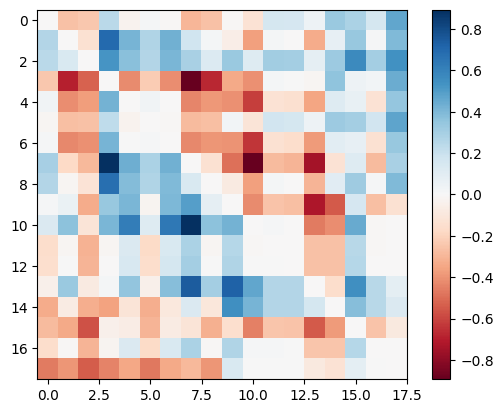

In [ ]:
plt.imshow(F_vv, "RdBu")
plt.colorbar()
plt.show()

In [ ]:
jnp.std(F_vv)

Array(0.30388444, dtype=float64)

In [ ]:
# instantiate NN ansatz
model = HFPS(
    n_hidden_fermions=2,
    num_blocks=2,
    kernel_size=3,
    jastrow_channels=4,
    N_occ=n,
    F_vv=F_vv,
    dtype=jnp.float32,
)

In [ ]:
state = qtx.state.Variational(model, max_parallel=2048)
sampler = qtx.sampler.ParticleHop(state, 2048)
optimizer = qtx.optimizer.SR(state, H)

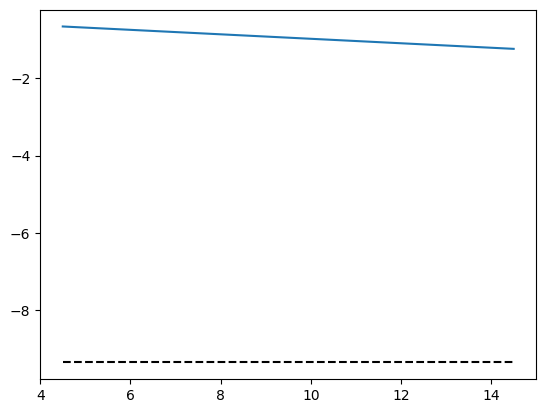

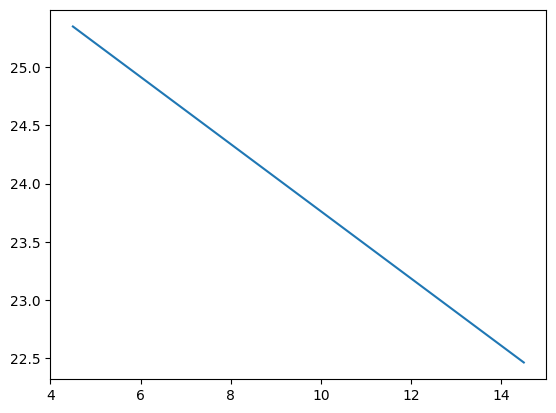

KeyboardInterrupt: 

In [ ]:
energy = qtx.utils.DataTracer()
VarE = qtx.utils.DataTracer()

training_rate = 0.01

for i in range(200):
    samples = sampler.sweep()
    step = optimizer.get_step(samples)
    state.update(step * training_rate)

    energy.append(optimizer.energy)
    VarE.append(optimizer.VarE)
    if i % 10 == 0:
        clear_output()
        energy.plot(batch=10, baseline=E)
        plt.show()
        VarE.plot(batch=10)
        plt.show()

In [ ]:
dense = state.todense().normalize()
nqs_energy = jnp.asarray(dense @ H @ dense)
rel_err = jnp.abs((nqs_energy - E) / E)
print(f"NQS energy: {nqs_energy}, relative error: {rel_err}")

fidelity = jnp.abs(dense @ GS) ** 2
print(f"Fidelity: {fidelity}")

NQS energy: -9.365389151850906, relative error: 0.0015301597770744
Fidelity: 0.14538081412127085


In [ ]:
print(f"Number of parameters: {state.nparams}")

Number of parameters: 840
